In [ ]:
# ==========================================
# CELL 1: CÀI ĐẶT MÔI TRƯỜNG & THƯ VIỆN
# ==========================================
# 1. Dọn dẹp thư mục cũ (tránh lỗi "destination path already exists")
!rm -rf /content/yolov10

# 2. Tải mã nguồn YOLOv10
!git clone https://github.com/THU-MIG/yolov10.git
%cd /content/yolov10

# 3. Vá lỗi phiên bản PyTorch (Ngăn lỗi torch==2.0.1)
!sed -i 's/torch==2.0.1/torch>=2.0.1/g' requirements.txt
!sed -i 's/torchvision==0.15.2/torchvision>=0.15.2/g' requirements.txt
!sed -i 's/torchaudio==2.0.2/torchaudio>=2.0.2/g' requirements.txt

# 4. Cài đặt các thư viện cần thiết
!pip install -q -r requirements.txt
!pip install -e .
!pip install -q ensemble-boxes

# 5. Tải trọng số YOLOv10l (Bản Large - Vũ khí hạng nặng)
!wget https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10s.pt

# 6. IMPORT THƯ VIỆN VÀ VÁ LỖI PYTORCH
import os
import shutil
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from ensemble_boxes import weighted_boxes_fusion
from sklearn.model_selection import GroupKFold
from ultralytics import YOLOv10 # <-- Thủ phạm gây lỗi là do thiếu dòng này!

_original_load = torch.load
def _custom_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _original_load(*args, **kwargs)
torch.load = _custom_load

print("✅ CELL 1: Cài đặt môi trường thành công 100%!")

Cloning into 'yolov10'...
remote: Enumerating objects: 20338, done.
remote: Total 20338 (delta 0), reused 0 (delta 0), pack-reused 20338 (from 1)
Receiving objects: 100% (20338/20338), 11.10 MiB | 17.25 MiB/s, done.
Resolving deltas: 100% (14354/14354), done.
/content/yolov10
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Could not find a version that satisfies the requirement onnxruntime==1.15.1 (from versions: 1.20.0, 1.20.1, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.23.0, 1.23.1, 1.23.2, 1.24.1, 1.24.2, 1.24.3, 1.24.4, 1.25.0, 1.25.1, 1.26.0, 1.27.0, 1.28.0, 1.29.0, 1.30.0)
ERROR: No matching distribution found for onnxruntime==1.15.1
Obtaining file:///content/yolov10
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproje

In [ ]:
# ==========================================
# CELL 2: TẢI DỮ LIỆU & TẠO THƯ MỤC
# ==========================================
# 1. Khai báo các đường dẫn
CSV_PATH = '/content/raw_data/images/vinbigdata/train.csv'
IMG_DIR = '/content/raw_data/images/vinbigdata/train'
BASE_DIR = '/content/vinbigdata_yolo'

# 2. Tạo cây thư mục mới chuẩn YOLO
for split in ['train', 'val']:
    os.makedirs(f'{BASE_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{BASE_DIR}/labels/{split}', exist_ok=True)

# 3. Tải dataset (Chỉ bỏ comment và chạy nếu máy ảo Colab bị reset mất dữ liệu)
"""
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download awsaf49/vinbigdata-512-image-dataset -p /content/raw_data/images/ --unzip
"""

print("✅ CELL 2: Thư mục đã sẵn sàng để chứa dữ liệu!")

✅ CELL 2: Thư mục đã sẵn sàng để chứa dữ liệu!


In [ ]:
# ==========================================
# CELL 3: TIỀN XỬ LÝ FILE CSV & GIỮ LẠI 1500 ẢNH BACKGROUND
# ==========================================
import numpy as np

print("Đang đọc file CSV và tách nhãn...")
df = pd.read_csv(CSV_PATH)

# 1. Tách riêng tập ảnh bệnh (Class 0-13) và tập ảnh bình thường (Class 14)
df_benh = df[df.class_id != 14].reset_index(drop=True)
df_khoe = df[df.class_id == 14].reset_index(drop=True)

# 2. Lấy mẫu ngẫu nhiên đúng 1500 image_id của ảnh bình thường
normal_image_ids = df_khoe['image_id'].unique()
np.random.seed(42) # Cố định seed để kết quả không bị đổi khi chạy lại
sampled_normal_ids = np.random.choice(normal_image_ids, 1500, replace=False)

# 3. Chuẩn hóa tọa độ (Chỉ áp dụng cho ảnh CÓ BỆNH)
df_benh['x_min'] = df_benh['x_min'] / df_benh['width']
df_benh['y_min'] = df_benh['y_min'] / df_benh['height']
df_benh['x_max'] = df_benh['x_max'] / df_benh['width']
df_benh['y_max'] = df_benh['y_max'] / df_benh['height']

for col in ['x_min', 'y_min', 'x_max', 'y_max']:
    df_benh[col] = df_benh[col].clip(0.0, 1.0)

# Gán lại df = df_benh để thuật toán WBF ở CELL 4 tiếp tục chạy đúng
df = df_benh

print(f"✅ Đã lưu riêng {len(sampled_normal_ids)} ảnh bình thường làm background.")
print(f"✅ CELL 3: Hoàn tất! Còn lại {len(df)} nhãn bệnh lý cần xử lý WBF.")

Đang đọc file CSV và tách nhãn...
✅ Đã lưu riêng 1500 ảnh bình thường làm background.
✅ CELL 3: Hoàn tất! Còn lại 36096 nhãn bệnh lý cần xử lý WBF.


In [ ]:
# # ==========================================
# # CELL 4: CHẠY THUẬT TOÁN WBF
# # ==========================================
# print("Đang chạy WBF để gộp các nhãn chồng chéo... (Sẽ mất khoảng 1-2 phút)")
# image_ids = df['image_id'].unique()
# wbf_results = []

# for img_id in tqdm(image_ids):
#     img_df = df[df['image_id'] == img_id]
#     rads = img_df['rad_id'].unique()

#     boxes_list, scores_list, labels_list = [], [], []
#     for rad in rads:
#         rad_df = img_df[img_df['rad_id'] == rad]
#         boxes_list.append(rad_df[['x_min', 'y_min', 'x_max', 'y_max']].values.tolist())
#         labels_list.append(rad_df['class_id'].values.tolist())
#         scores_list.append([1.0] * len(rad_df)) # Trọng số các bác sĩ bằng nhau

#     # Gộp bằng WBF
#     boxes, scores, labels = weighted_boxes_fusion(
#         boxes_list, scores_list, labels_list,
#         iou_thr=0.4, skip_box_thr=0.0
#     )

#     for box, label in zip(boxes, labels):
#         wbf_results.append({
#             'image_id': img_id,
#             'class_id': int(label),
#             'x_min': box[0], 'y_min': box[1], 'x_max': box[2], 'y_max': box[3]
#         })

# df_wbf = pd.DataFrame(wbf_results)

# # Chuyển đổi sang hệ tọa độ YOLO (x_center, y_center, width, height)
# df_wbf['x_center'] = (df_wbf['x_min'] + df_wbf['x_max']) / 2.0
# df_wbf['y_center'] = (df_wbf['y_min'] + df_wbf['y_max']) / 2.0
# df_wbf['w'] = df_wbf['x_max'] - df_wbf['x_min']
# df_wbf['h'] = df_wbf['y_max'] - df_wbf['y_min']

# print(f"\n✅ CELL 4: WBF hoàn tất! Đã rút gọn xuống còn {len(df_wbf)} nhãn chuẩn vàng.")

In [ ]:
# ==========================================
# CELL 4: CHẠY THUẬT TOÁN WBF (CÓ BỘ LỌC ĐỒNG THUẬN)
# ==========================================
print("Đang chạy WBF để gộp các nhãn chồng chéo... (Sẽ mất khoảng 1-2 phút)")
image_ids = df['image_id'].unique()
wbf_results = []

# --- NGƯỠNG ĐỒNG THUẬN ---
# 0.0: Giữ tất cả (như cũ)
# 0.4: Giữ các hộp có ít nhất 2 bác sĩ đồng ý (ĐỀ XUẤT ĐỂ TĂNG mAP)
# 0.7: Chỉ giữ các hộp cả 3 bác sĩ đều đồng ý (Rất khắt khe)
CONSENSUS_THRESHOLD = 0.4

for img_id in tqdm(image_ids):
    img_df = df[df['image_id'] == img_id]

    # Lấy danh sách TẤT CẢ các bác sĩ đã chẩn đoán ảnh này
    rads = img_df['rad_id'].unique()

    boxes_list, scores_list, labels_list = [], [], []

    for rad in rads:
        rad_df = img_df[img_df['rad_id'] == rad]
        boxes_list.append(rad_df[['x_min', 'y_min', 'x_max', 'y_max']].values.tolist())
        labels_list.append(rad_df['class_id'].values.tolist())
        # Mỗi bác sĩ chẩn đoán được đánh mức tin cậy ban đầu là 1.0
        scores_list.append([1.0] * len(rad_df))

    # Gộp bằng WBF
    boxes, scores, labels = weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        iou_thr=0.4, skip_box_thr=0.0
    )

    # ÁP DỤNG BỘ LỌC ĐỒNG THUẬN TỪ ĐIỂM SỐ WBF
    for box, score, label in zip(boxes, scores, labels):
        if score > CONSENSUS_THRESHOLD:
            wbf_results.append({
                'image_id': img_id,
                'class_id': int(label),
                'x_min': box[0], 'y_min': box[1], 'x_max': box[2], 'y_max': box[3],
                'wbf_score': score # Tùy chọn: Lưu lại điểm số để theo dõi
            })

df_wbf = pd.DataFrame(wbf_results)

# Chuyển đổi sang hệ tọa độ YOLO (x_center, y_center, width, height)
df_wbf['x_center'] = (df_wbf['x_min'] + df_wbf['x_max']) / 2.0
df_wbf['y_center'] = (df_wbf['y_min'] + df_wbf['y_max']) / 2.0
df_wbf['w'] = df_wbf['x_max'] - df_wbf['x_min']
df_wbf['h'] = df_wbf['y_max'] - df_wbf['y_min']

print(f"\n✅ CELL 4: WBF hoàn tất! Đã rút gọn xuống còn {len(df_wbf)} nhãn chuẩn vàng chất lượng cao.")

Đang chạy WBF để gộp các nhãn chồng chéo... (Sẽ mất khoảng 1-2 phút)


100%|██████████| 4394/4394 [00:30<00:00, 146.25it/s]


✅ CELL 4: WBF hoàn tất! Đã rút gọn xuống còn 8824 nhãn chuẩn vàng chất lượng cao.


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Lấy danh sách tất cả các ID ảnh có bệnh
all_disease_imgs = df_wbf['image_id'].unique()

# 2. Chia ngẫu nhiên 80% Train và 20% Val
train_imgs, val_imgs = train_test_split(all_disease_imgs, test_size=0.2, random_state=42)

# 3. Trộn ảnh background (bình thường) vào tập Train/Val
# Giả sử ở CELL 3 bạn đã lấy 500 ảnh bình thường (sampled_normal_ids)
# Ta sẽ chia 500 ảnh này thành: 400 cho Train và 100 cho Val
train_normal_imgs = sampled_normal_ids[:1200]
val_normal_imgs = sampled_normal_ids[1200:]

# 4. Gộp danh sách ảnh bệnh và ảnh khỏe lại với nhau
train_imgs = np.concatenate([train_imgs, train_normal_imgs])
val_imgs = np.concatenate([val_imgs, val_normal_imgs])

# (Hàm export_yolo_data bên dưới bạn giữ nguyên)
def export_yolo_data(img_list, split_name):
    print(f"Đang copy ảnh và tạo file .txt cho tập {split_name}...")
    for img_id in tqdm(img_list):
        # Những ảnh bình thường sẽ trả về img_labels rỗng
        img_labels = df_wbf[df_wbf['image_id'] == img_id]

        # Tạo file .txt (Nếu ảnh bình thường, vòng lặp for bên trong tự bỏ qua -> File sinh ra sẽ rỗng)
        with open(f"{BASE_DIR}/labels/{split_name}/{img_id}.txt", 'w') as f:
            for _, row in img_labels.iterrows():
                f.write(f"{int(row['class_id'])} {row['x_center']:.6f} {row['y_center']:.6f} {row['w']:.6f} {row['h']:.6f}\n")

        # Copy ảnh
        src_img = f"{IMG_DIR}/{img_id}.png"
        dst_img = f"{BASE_DIR}/images/{split_name}/{img_id}.png"

        if os.path.exists(src_img) and not os.path.exists(dst_img):
            shutil.copy(src_img, dst_img)

export_yolo_data(train_imgs, 'train')
export_yolo_data(val_imgs, 'val')

print(f"\n✅ CELL 5: Dữ liệu đã sẵn sàng 100% cho YOLO! Đã bao gồm ảnh Background.")

Đang copy ảnh và tạo file .txt cho tập train...


100%|██████████| 4591/4591 [00:08<00:00, 560.56it/s]


Đang copy ảnh và tạo file .txt cho tập val...


100%|██████████| 1148/1148 [00:01<00:00, 675.34it/s]


✅ CELL 5: Dữ liệu đã sẵn sàng 100% cho YOLO! Đã bao gồm ảnh Background.


In [ ]:
# =======================================================
# TIỀN XỬ LÝ CHUYÊN SÂU: ALBUMENTATIONS + OVERSAMPLING
# =======================================================
!pip install -q -U albumentations # Cập nhật thư viện bản mới nhất

import os
import cv2
import shutil
import numpy as np
import albumentations as A
from tqdm import tqdm

OLD_BASE_DIR = '/content/vinbigdata_yolo'
NEW_BASE_DIR = '/content/vinbigdata_yolo_optimized'

# 1. Khởi tạo cây thư mục
for split in ['train', 'val']:
    os.makedirs(f"{NEW_BASE_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{NEW_BASE_DIR}/labels/{split}", exist_ok=True)

# 2. Định nghĩa các nhóm cần nhân bản
GROUP_X3 = [1, 4, 12]   # < 500 boxes
GROUP_X2 = [2, 5, 6]    # 500-1000 boxes

# 3. ĐỊNH NGHĨA CÁC PIPELINE BIẾN ĐỔI (ALBUMENTATIONS)

# Pipeline Gốc (Dành cho mọi ảnh: Chỉ chạy CLAHE)
base_transform = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.1))

# Pipeline Nhiễu loạn (Dành riêng cho các bản copy Oversampling)
aug_transform = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
    # Nhóm Hình học: Xoay tối đa 5 độ, dịch chuyển 5%, viền đen (mô phỏng X-quang)
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.03, rotate_limit=5,
                       border_mode=cv2.BORDER_CONSTANT, value=0, p=0.8),
    # Nhóm Quang học: Thay đổi sáng/tối và thêm nhiễu hạt
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.6),
    A.GaussNoise(var_limit=(10.0, 40.0), p=0.4),
    # Nhóm Che khuất: Thả 1-3 mảng đen nhỏ chống học vẹt
    A.CoarseDropout(max_holes=3, max_height=40, max_width=40,
                    min_holes=1, min_height=15, min_width=15, p=0.4)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))
# min_visibility=0.2: Bbox nào bị xoay/che mất quá 80% sẽ tự động bị xóa bỏ để tránh nhiễu AI


print("Bắt đầu xử lý với Albumentations...")

for split in ['train', 'val']:
    img_dir = f"{OLD_BASE_DIR}/images/{split}"
    lbl_dir = f"{OLD_BASE_DIR}/labels/{split}"

    if not os.path.exists(img_dir): continue
    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))]

    for filename in tqdm(img_files, desc=f"Đang xử lý tập {split.upper()}"):
        base_name = os.path.splitext(filename)[0]
        img_path = os.path.join(img_dir, filename)
        lbl_path = os.path.join(lbl_dir, f"{base_name}.txt")

        # Đọc ảnh gốc
        image = cv2.imread(img_path)
        if image is None: continue
        # Albumentations yêu cầu hệ màu RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Đọc tọa độ Bounding Box
        bboxes = []
        class_labels = []
        multiplier = 1

        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        c_id = int(parts[0])
                        x_c, y_c, w, h = map(float, parts[1:5])

                        # Fix an toàn: Ép tọa độ không vượt quá giới hạn [0, 1] của Albumentations
                        x_c = np.clip(x_c, 0.001, 0.999)
                        y_c = np.clip(y_c, 0.001, 0.999)
                        w = np.clip(w, 0.001, min(w, x_c*2, (1-x_c)*2))
                        h = np.clip(h, 0.001, min(h, y_c*2, (1-y_c)*2))

                        bboxes.append([x_c, y_c, w, h])
                        class_labels.append(c_id)

            # Tính toán số lần bơm dữ liệu (Chỉ áp dụng trên tập Train)
            if split == 'train':
                if any(c in GROUP_X3 for c in class_labels): multiplier = 3
                elif any(c in GROUP_X2 for c in class_labels): multiplier = 2

        # 4. Thực thi biến đổi và lưu file
        for i in range(multiplier):
            new_img_name = f"{base_name}.png" if i == 0 else f"{base_name}_aug{i}.png"
            new_lbl_name = f"{base_name}.txt" if i == 0 else f"{base_name}_aug{i}.txt"

            # Bản đầu tiên luôn giữ góc/tọa độ gốc (chỉ chạy CLAHE)
            if i == 0:
                transformed = base_transform(image=image, bboxes=bboxes, class_labels=class_labels)
            # Các bản sau áp dụng Xoay, Nhiễu, Che khuất...
            else:
                transformed = aug_transform(image=image, bboxes=bboxes, class_labels=class_labels)

            # Chuyển ngược lại thành BGR để lưu bằng cv2
            out_image = cv2.cvtColor(transformed['image'], cv2.COLOR_RGB2BGR)
            out_bboxes = transformed['bboxes']
            out_classes = transformed['class_labels']

            # Lưu ảnh
            cv2.imwrite(f"{NEW_BASE_DIR}/images/{split}/{new_img_name}", out_image)

            # Lưu nhãn mới (với tọa độ đã được Albumentations tính toán lại)
            if len(out_bboxes) > 0:
                with open(f"{NEW_BASE_DIR}/labels/{split}/{new_lbl_name}", 'w') as f:
                    for cls_id, box in zip(out_classes, out_bboxes):
                        f.write(f"{cls_id} {box[0]:.6f} {box[1]:.6f} {box[2]:.6f} {box[3]:.6f}\n")

print("\n✅ Hoàn tất siêu dữ liệu! Dữ liệu của bạn đã được gia cố sức mạnh toàn diện.")

/usr/local/lib/python3.13/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_9002/423638064.py:36: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.03, rotate_limit=5,
/tmp/ipykernel_9002/423638064.py:40: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 40.0), p=0.4),
/tmp/ipykernel_9002/423638064.py:42: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=3, max_height=40, max_width=40,


Bắt đầu xử lý với Albumentations...


Đang xử lý tập VAL: 100%|██████████| 1148/1148 [00:30<00:00, 37.77it/s]


✅ Hoàn tất siêu dữ liệu! Dữ liệu của bạn đã được gia cố sức mạnh toàn diện.


In [ ]:
# ==========================================
# CELL 6: HUẤN LUYỆN MÔ HÌNH (TRAIN)
# ==========================================
# Tạo file yaml cấu hình
yaml_content = f"""
path: {NEW_BASE_DIR}
train: images/train
val: images/val
nc: 14
names: ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']
"""
with open(f'{NEW_BASE_DIR}/data.yaml', 'w') as f:
    f.write(yaml_content)

print("Bắt đầu huấn luyện mô hình YOLOv10l (Large)...")

Bắt đầu huấn luyện mô hình YOLOv10l (Large)...


In [ ]:
import os

# Đường dẫn đến thư mục dataset đã tối ưu (đổi tên nếu bạn lưu ở nơi khác)
NEW_BASE_DIR = '/content/vinbigdata_yolo_optimized'

train_dir = f"{NEW_BASE_DIR}/images/train"
val_dir = f"{NEW_BASE_DIR}/images/val"

# Đếm số lượng file có định dạng ảnh
train_count = len([f for f in os.listdir(train_dir) if f.endswith(('.png', '.jpg'))]) if os.path.exists(train_dir) else 0
val_count = len([f for f in os.listdir(val_dir) if f.endswith(('.png', '.jpg'))]) if os.path.exists(val_dir) else 0

print("📊 THỐNG KÊ SỐ LƯỢNG ẢNH SAU TIỀN XỬ LÝ:")
print("-" * 45)
print(f"Tập TRAIN (Đã bơm thêm dữ liệu) : {train_count} ảnh")
print(f"Tập VAL   (Giữ nguyên số lượng) : {val_count} ảnh")
print("-" * 45)
print(f"TỔNG CỘNG                       : {train_count + val_count} ảnh")

📊 THỐNG KÊ SỐ LƯỢNG ẢNH SAU TIỀN XỬ LÝ:
---------------------------------------------
Tập TRAIN (Đã bơm thêm dữ liệu) : 5256 ảnh
Tập VAL   (Giữ nguyên số lượng) : 1148 ảnh
---------------------------------------------
TỔNG CỘNG                       : 6404 ảnh


In [ ]:


# # Dùng bản YOLOv10l (Large) để có mạng nơ-ron đủ sâu cho dữ liệu y tế
# model = YOLOv10('yolov10s.pt')

# model.train(
#     data=f'{NEW_BASE_DIR}/data.yaml',
#     epochs=100,           # Tăng epochs
#     imgsz=512,            # TĂNG ĐỘ PHÂN GIẢI
#     batch=64,             # HẠ BATCH SIZE
#     device=0,
#     workers=8,
#     patience=25,          # Dừng sớm nếu sau 25 epochs mAP không tăng
#     close_mosaic=15,
#     project='VinBigData_Detection',
#     name='yolov10l_img640'
# )

# print("✅ CELL 6: Quá trình huấn luyện đã kết thúc!")

In [ ]:
from ultralytics import YOLO

# Trỏ đến file trọng số cuối cùng được lưu lại
model = YOLO('/content/last.pt')

# Tiếp tục huấn luyện với resume=True
results = model.train(resume=True)

New https://pypi.org/project/ultralytics/8.4.171 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.34 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/content/last.pt, data=/content/vinbigdata_yolo_optimized/data.yaml, epochs=100, time=None, patience=25, batch=64, imgsz=512, save=True, save_period=-1, val_period=1, cache=False, device=0, workers=8, project=VinBigData_Detection, name=yolov10l_img640, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=15, resume=/content/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nm

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin



                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1     36096  ultralytics.nn.modules.block.SCDown          [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1    137728  ultralytics.nn.modules.block.SCDown          [256

...

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


/content/yolov10/ultralytics/data/augment.py:846: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
/usr/local/lib/python3.13/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
val: Scanning /content/vinbigdata_yolo_optimized/labels/val.cache... 848 images, 300 backgrounds, 0 corrupt: 100%|██████████| 1148/1148 [00:00<?, ?it/s]


Plotting labels to VinBigData_Detection/yolov10l_img640/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000556, momentum=0.9) with parameter groups 99 weight(decay=0.0), 112 weight(decay=0.0005), 111 bias(decay=0.0)
Resuming training /content/last.pt from epoch 80 to 100 total epochs
TensorBoard: model graph visualization added ✅
Image sizes 512 train, 512 val
Using 2 dataloader workers
Logging results to VinBigData_Detection/yolov10l_img640
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/83 [00:01<?, ?it/s]


AttributeError: 'str' object has no attribute 'view'

In [ ]:
!yolo train resume model=/content/last.pt

New https://pypi.org/project/ultralytics/8.4.171 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.34 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/content/last.pt, data=/content/vinbigdata_yolo_optimized/data.yaml, epochs=100, time=None, patience=25, batch=64, imgsz=512, save=True, save_period=-1, val_period=1, cache=False, device=0, workers=8, project=VinBigData_Detection, name=yolov10l_img640, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=15, resume=/content/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nm

In [ ]:
!sed -i 's/torch.load(file, map_location="cpu")/torch.load(file, map_location="cpu", weights_only=False)/g' /content/yolov10/ultralytics/nn/tasks.py

📊 THỐNG KÊ SỐ LƯỢNG BỆNH LÝ TỪ FILE CSV:
--------------------------------------------------
Class  0 | Aortic enlargement   |   7162 boxes
Class  1 | Atelectasis          |    279 boxes
Class  2 | Calcification        |    960 boxes
Class  3 | Cardiomegaly         |   5427 boxes
Class  4 | Consolidation        |    556 boxes
Class  5 | ILD                  |   1000 boxes
Class  6 | Infiltration         |   1247 boxes
Class  7 | Lung Opacity         |   2483 boxes
Class  8 | Nodule/Mass          |   2580 boxes
Class  9 | Other lesion         |   2203 boxes
Class 10 | Pleural effusion     |   2476 boxes
Class 11 | Pleural thickening   |   4842 boxes
Class 12 | Pneumothorax         |    226 boxes
Class 13 | Pulmonary fibrosis   |   4655 boxes
--------------------------------------------------
TỔNG CỘNG: 36096 bounding boxes


/tmp/ipykernel_9002/3314747460.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_list, y=class_names, palette='magma')


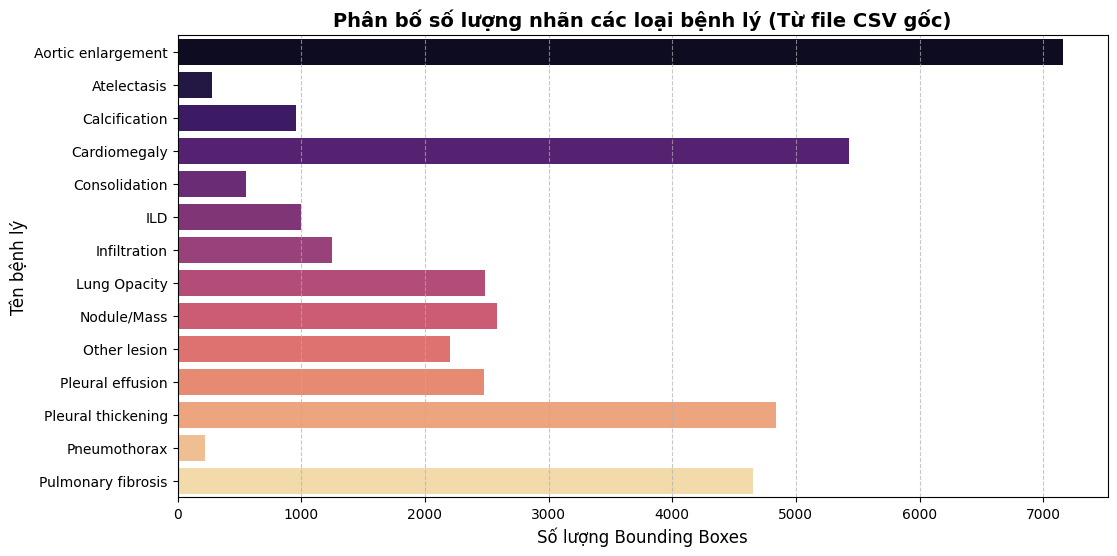

In [ ]:
# ==========================================
# THỐNG KÊ SỐ LƯỢNG NHÃN TỪ FILE CSV GỐC
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đường dẫn đến file CSV của bạn (nhớ sửa lại nếu khác)
csv_path = '/content/raw_data/images/vinbigdata/train.csv'

# Đọc file CSV
df = pd.read_csv(csv_path)

# Lọc bỏ Class 14 (No finding - ảnh bình thường)
df_abnormal = df[df['class_id'] != 14]

# Đếm số lượng bounding box cho mỗi class_id (từ 0 đến 13)
class_counts = df_abnormal['class_id'].value_counts().sort_index()

# Tên 14 loại bệnh lý
class_names = [
    'Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly',
    'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass',
    'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis'
]

# 2. In ra bảng thống kê dạng Text
print("📊 THỐNG KÊ SỐ LƯỢNG BỆNH LÝ TỪ FILE CSV:")
print("-" * 50)
total_boxes = 0
counts_list = []
for i in range(14):
    count = class_counts.get(i, 0)
    counts_list.append(count)
    total_boxes += count
    print(f"Class {i:2d} | {class_names[i]:<20} | {count:6d} boxes")
print("-" * 50)
print(f"TỔNG CỘNG: {total_boxes} bounding boxes")

# 3. Vẽ biểu đồ trực quan
plt.figure(figsize=(12, 6))
sns.barplot(x=counts_list, y=class_names, palette='magma')
plt.title('Phân bố số lượng nhãn các loại bệnh lý (Từ file CSV gốc)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng Bounding Boxes', fontsize=12)
plt.ylabel('Tên bệnh lý', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# ==========================================
# THỐNG KÊ SỐ LƯỢNG NHÃN (LABELS) SAU KHI LỌC & WBF
# ==========================================
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Tên các nhãn (Class 0 đến 13)
class_names = [
    'Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly',
    'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass',
    'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis'
]

# Đường dẫn đến thư mục chứa file nhãn YOLO của bạn
# (Nếu biến BASE_DIR chưa có trong bộ nhớ, hãy bỏ comment dòng dưới)
# BASE_DIR = '/content/vinbigdata_yolo'
label_dirs = [f'{BASE_DIR}/labels/train', f'{BASE_DIR}/labels/val']

class_counts = Counter()

# Quét đọc toàn bộ file .txt để đếm class_id
for d in label_dirs:
    if os.path.exists(d):
        for file in os.listdir(d):
            if file.endswith('.txt'):
                with open(os.path.join(d, file), 'r') as f:
                    for line in f.readlines():
                        if line.strip():
                            class_id = int(line.split()[0])
                            class_counts[class_id] += 1

# 1. In ra bảng thống kê dạng Text
print(f"📊 THỐNG KÊ SỐ LƯỢNG BỆNH LÝ TỪ {len(label_dirs)} TẬP (TRAIN & VAL):")
print("-" * 50)
total_boxes = 0
counts_list = []
for i in range(14):
    count = class_counts.get(i, 0)
    counts_list.append(count)
    total_boxes += count
    print(f"Class {i:2d} | {class_names[i]:<20} | {count:5d} boxes")
print("-" * 50)
print(f"TỔNG CỘNG: {total_boxes} bounding boxes")

# 2. Vẽ biểu đồ trực quan
plt.figure(figsize=(12, 6))
sns.barplot(x=counts_list, y=class_names, palette='viridis')
plt.title('Phân bố số lượng nhãn các loại bệnh lý (Class 0-13)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng Bounding Boxes', fontsize=12)
plt.ylabel('Tên bệnh lý', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# ==========================================
# ĐÁNH GIÁ MÔ HÌNH TOÀN DIỆN VỚI TTA (VALIDATION)
# ==========================================
from ultralytics import YOLO

# 1. Đường dẫn tới mô hình tốt nhất của bạn
weights_path = '/content/yolov10/VinBigData_Detection/yolov10l_img640/weights/last.pt'

print("Đang tải mô hình và kích hoạt chế độ TTA...")
model = YOLO(weights_path)

print("Bắt đầu đánh giá trên tập Validation...")
# 2. Chạy đánh giá với augment=True
metrics = model.val(
    data=f'{NEW_BASE_DIR}/data.yaml',
    imgsz=512,        # Khớp với kích thước ảnh bạn đã dùng để train
    batch=128,         # Batch size cho khâu đánh giá
    augment=True,     # <--- CHÌA KHÓA: Kích hoạt Test-Time Augmentation
    split='val',      # Đảm bảo chạy trên tập Validation
    conf=0.31,       # Mức conf rất thấp để YOLO tính toán mAP chi tiết và chính xác nhất
    iou=0.6        # Ngưỡng NMS loại bỏ các hộp chồng chéo
)

print("✅ Đã hoàn tất đánh giá!")
print(f"🏆 Điểm mAP@50 tổng quát (với TTA): {metrics.box.map50:.4f}")
print(f"🏆 Điểm mAP@50-95 tổng quát (với TTA): {metrics.box.map:.4f}")

Đang tải mô hình và kích hoạt chế độ TTA...
Bắt đầu đánh giá trên tập Validation...


NameError: name 'NEW_BASE_DIR' is not defined

In [ ]:
# Mở trực tiếp biểu đồ F1-Curve trên Colab
from IPython.display import Image, display

# Đường dẫn đến thư mục kết quả mới nhất của bạn (số 2)
# Nếu bạn chạy lệnh model.val() thì nó có thể nằm trong thư mục val (VD: VinBigData_Detection/val/)
# Dưới đây là đường dẫn mặc định trong thư mục train:
curve_path = '/content/yolov10/VinBigData_Detection/yolov10l_wbf_kfold/F1_curve.png'

display(Image(filename=curve_path, width=800))

In [ ]:
# ==========================================
# CELL 7: LƯU KẾT QUẢ SANG GOOGLE DRIVE
# ==========================================
from google.colab import drive

# 1. Kết nối với Google Drive của bạn (Sẽ có một bảng hiện lên yêu cầu bạn cấp quyền)
drive.mount('/content/drive')

print("Đang copy thư mục kết quả huấn luyện sang Google Drive...")

# 2. Tạo một thư mục trên Drive để chứa dự án (nếu chưa có)
!mkdir -p /content/drive/MyDrive/VinBigData_Project

# 3. Copy toàn bộ thư mục kết quả (bao gồm trọng số best.pt) sang Drive
# (Bạn có thể thay /content/VinBigData_Detection bằng tên thư mục khác trong ảnh nếu muốn)
!cp -r /content/yolov10 /content/drive/MyDrive/VinBigData_Project/

print("✅ Đã lưu thành công! Bạn có thể vào Google Drive để kiểm tra.")

Mounted at /content/drive
Đang copy thư mục kết quả huấn luyện sang Google Drive...
✅ Đã lưu thành công! Bạn có thể vào Google Drive để kiểm tra.


In [ ]:
import os
import random
import cv2
from google.colab.patches import cv2_imshow # Công cụ hiển thị ảnh chống cuộn của Colab

# Đường dẫn
CHECK_DIR = '/content/vinbigdata_yolo_optimized/images/train'
LBL_DIR = '/content/vinbigdata_yolo_optimized/labels/train'

img_files = [f for f in os.listdir(CHECK_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if img_files:
    sample_img = random.choice(img_files)
    img_path = os.path.join(CHECK_DIR, sample_img)
    base_name = os.path.splitext(sample_img)[0]
    lbl_path = os.path.join(LBL_DIR, f"{base_name}.txt")

    img = cv2.imread(img_path)

    if img is not None:
        h, w, _ = img.shape
        print(f"✅ Ảnh: {sample_img} | Kích thước: {w}x{h}")

        # Vẽ Box
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        x_c, y_c, bw, bh = map(float, parts[1:5])

                        x1 = int((x_c - bw / 2) * w)
                        y1 = int((y_c - bh / 2) * h)
                        x2 = int((x_c + bw / 2) * w)
                        y2 = int((y_c + bh / 2) * h)

                        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
                        cv2.putText(img, f"Class {class_id}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        else:
            print("Không có nhãn (Ảnh bình thường).")

        # Hiển thị trực tiếp (Đảm bảo luôn hiện 100% trên màn hình)
        cv2_imshow(img)
else:
    print("Không tìm thấy ảnh trong thư mục.")

In [ ]:
import os
import random
import cv2
from google.colab.patches import cv2_imshow # Công cụ hiển thị ảnh chống cuộn của Colab

# Đường dẫn
CHECK_DIR = '/content/vinbigdata_yolo/images/train'
LBL_DIR = '/content/vinbigdata_yolo/labels/train'

img_files = [f for f in os.listdir(CHECK_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if img_files:
    sample_img = '53d4fbf11ca8be107a343df37ca9eddc.png'
    img_path = os.path.join(CHECK_DIR, sample_img)
    base_name = os.path.splitext(sample_img)[0]
    lbl_path = os.path.join(LBL_DIR, f"{base_name}.txt")

    img = cv2.imread(img_path)

    if img is not None:
        h, w, _ = img.shape
        print(f"✅ Ảnh: {sample_img} | Kích thước: {w}x{h}")

        # Vẽ Box
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        x_c, y_c, bw, bh = map(float, parts[1:5])

                        x1 = int((x_c - bw / 2) * w)
                        y1 = int((y_c - bh / 2) * h)
                        x2 = int((x_c + bw / 2) * w)
                        y2 = int((y_c + bh / 2) * h)

                        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
                        cv2.putText(img, f"Class {class_id}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        else:
            print("Không có nhãn (Ảnh bình thường).")

        # Hiển thị trực tiếp (Đảm bảo luôn hiện 100% trên màn hình)
        cv2_imshow(img)
else:
    print("Không tìm thấy ảnh trong thư mục.")